# Split Inference — July 27th Results

Comparison of the two scheduling modes captured on 2026-07-27:

| Run | Folder |
|---|---|
| **Dynamic** | `results/July27th/dynamic` |
| **Split** | `results/July27th/split` |

Both runs process the identical workload — 504 batches / 16 128 frames across
2 clusters (`intermediate_queue_0`, `intermediate_queue_1`) on 12 devices.

Every chart is written to `results/July27th/imgs/`.

## 0 · Setup — paths, palette, chart style

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================
# PATHS
# ============================================================
ROOT     = Path(r"D:\SplitInference\Optimizer\split_inference_test")
RESULTS  = ROOT / "results" / "July27th"
IMG_DIR  = RESULTS / "imgs"
IMG_DIR.mkdir(parents=True, exist_ok=True)

RUNS = {
    "Dynamic": RESULTS / "dynamic",
    "Split":   RESULTS / "split",
}

CLUSTER_LABEL = {
    "intermediate_queue_0": "Cluster 0",
    "intermediate_queue_1": "Cluster 1",
}

print("Results dir :", RESULTS)
print("Image dir   :", IMG_DIR)
for name, path in RUNS.items():
    print(f"  {name:<8} -> {path}  (exists={path.exists()})")

Results dir : D:\SplitInference\Optimizer\split_inference_test\results\July27th
Image dir   : D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs
  Dynamic  -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\dynamic  (exists=True)
  Split    -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\split  (exists=True)


In [2]:
# ============================================================
# PALETTE
# ------------------------------------------------------------
# Categorical slots taken in fixed order (never cycled) from the validated
# reference palette. Charts here use at most 3 slots.
#   slot 1 blue  <-> slot 2 orange : all-pairs CVD dE 24.7, normal dE 33.6
#   slot 3 aqua added              : all-pairs CVD dE  9.2, normal dE 24.0
# Aqua sits at 2.74:1 on the light surface -> the relief rule applies, so every
# chart that uses slot 3 carries visible direct labels.
# ============================================================
SURFACE   = "#fcfcfb"   # chart surface
PAGE      = "#f9f9f7"
INK       = "#0b0b0b"   # primary
INK_2     = "#52514e"   # secondary
MUTED     = "#898781"   # axis / tick labels
GRID      = "#e1e0d9"   # hairline gridline
AXIS      = "#c3c2b7"   # baseline

S1 = "#2a78d6"   # blue    — slot 1
S2 = "#eb6834"   # orange  — slot 2
S3 = "#1baf7a"   # aqua    — slot 3
DIVERGE_POS, DIVERGE_NEG = S1, "#e34948"   # blue <-> red diverging pair

MODE_COLOR    = {"Dynamic": S1, "Split": S2}
ROLE_COLOR    = {"cloud":   S1, "edge":  S2}
CLUSTER_COLOR = {"Cluster 0": S1, "Cluster 1": S2}

# ============================================================
# STYLE — thin marks, recessive solid hairline grid, no mark borders
# ============================================================
mpl.rcParams.update({
    "figure.facecolor":   SURFACE,
    "axes.facecolor":     SURFACE,
    "savefig.facecolor":  SURFACE,
    "font.family":        ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size":          10,
    "axes.titlesize":     13,
    "axes.titleweight":   "semibold",
    "axes.titlecolor":    INK,
    "axes.titlepad":      12,
    "axes.labelsize":     10.5,
    "axes.labelcolor":    INK_2,
    "axes.edgecolor":     AXIS,
    "axes.linewidth":     0.8,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         GRID,
    "grid.linestyle":     "-",       # solid hairline — never dashed
    "grid.linewidth":     0.8,
    "xtick.color":        MUTED,
    "ytick.color":        MUTED,
    "xtick.labelsize":    9.5,
    "ytick.labelsize":    9.5,
    "xtick.major.size":   0,
    "ytick.major.size":   0,
    "legend.frameon":     False,
    "legend.fontsize":    9.5,
    "legend.labelcolor":  INK_2,
    "figure.dpi":         110,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

SAVED = []   # running manifest of written images


def finish(fig, filename, hide_spines=("top", "right")):
    """Tidy spines, save to IMG_DIR, record in the manifest, show."""
    for ax in fig.get_axes():
        for side in hide_spines:
            ax.spines[side].set_visible(False)
        ax.set_axisbelow(True)
    out = IMG_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches="tight", facecolor=SURFACE)
    SAVED.append(filename)
    print(f"saved -> {out}")
    plt.show()


def label_bars(ax, bars, fmt="{:.2f}", dy=3, fontsize=9, color=INK_2):
    """Direct value labels above bars (the relief for sub-3:1 fills)."""
    for bar in bars:
        h = bar.get_height()
        if np.isnan(h):
            continue
        ax.annotate(fmt.format(h),
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, dy), textcoords="offset points",
                    ha="center", va="bottom", fontsize=fontsize, color=color)


# Bars carry a surface-coloured edge: that is the 2px gap between adjacent
# fills, not a contrasting border drawn to separate them.
BAR_KW = dict(edgecolor=SURFACE, linewidth=1.2)
LINE_KW = dict(linewidth=2.0, solid_capstyle="round")
MARK_KW = dict(markersize=6, markeredgecolor=SURFACE, markeredgewidth=1.4)

print("Palette and style ready.")

Palette and style ready.


## 1 · Log parsers

In [3]:
# ============================================================
# Generic  key=value  log parser
# All logs share the shape:  <timestamp_ns> [FLAG] key=value key=value ...
# ============================================================
KV = re.compile(r"(\w+)=([^\s]+)")


def parse_kv_line(line):
    """Return (timestamp, flags, {key: value}) for one log line."""
    parts = line.split()
    if not parts:
        return None
    ts = int(parts[0]) if parts[0].isdigit() else None
    kv = {k: v for k, v in KV.findall(line)}
    flags = [p for p in parts[1:] if "=" not in p and p.isupper()]
    return ts, flags, kv


def num(v):
    """'55.06%' -> 55.06 ; '336' -> 336.0 ; else None."""
    if v is None:
        return np.nan
    try:
        return float(str(v).rstrip("%"))
    except ValueError:
        return np.nan


def read_lines(path):
    if not Path(path).exists():
        print(f"!! missing: {path}")
        return []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        return [ln.rstrip("\n") for ln in f if ln.strip()]


# ------------------------------------------------------------
# fps_cluster.log   -> per-cluster + SYSTEM throughput summary
# ------------------------------------------------------------
def parse_fps_summary(run, path):
    rows = []
    for ln in read_lines(path):
        ts, flags, kv = parse_kv_line(ln)
        scope = CLUSTER_LABEL.get(kv.get("cluster"), "System" if "SYSTEM" in flags else None)
        if scope is None:
            continue
        rows.append(dict(run=run, scope=scope,
                         fps=num(kv.get("fps")),
                         steady_fps=num(kv.get("steady_fps", kv.get("fps"))),
                         done=num(kv.get("done")), frames=num(kv.get("frames")),
                         share=num(kv.get("share"))))
    return rows


# ------------------------------------------------------------
# fps_cluster_ns.log  -> per-cluster rolling window FPS timeline
# ------------------------------------------------------------
def parse_fps_timeline(run, path):
    rows = []
    for ln in read_lines(path):
        ts, _, kv = parse_kv_line(ln)
        if "window_fps" not in kv:
            continue          # warm-up rows before the window fills
        rows.append(dict(run=run,
                         cluster=CLUSTER_LABEL.get(kv["cluster"], kv["cluster"]),
                         ts=ts, done=int(num(kv["done"])),
                         window_fps=num(kv["window_fps"])))
    return rows


# ------------------------------------------------------------
# batch_done_ns.log  -> system-wide window FPS timeline
#   "<ts>"        during warm-up
#   "<ts> <fps>"  once the window is full
# ------------------------------------------------------------
def parse_batch_done(run, path):
    rows, idx = [], 0
    for ln in read_lines(path):
        parts = ln.split()
        idx += 1
        if len(parts) == 2:
            rows.append(dict(run=run, batch=idx, ts=int(parts[0]),
                             window_fps=float(parts[1])))
    return rows


# ------------------------------------------------------------
# latency_cluster.log -> service (per role) + e2e latency stats
# ------------------------------------------------------------
def parse_latency(run, path):
    rows = []
    for ln in read_lines(path):
        ts, flags, kv = parse_kv_line(ln)
        scope = CLUSTER_LABEL.get(kv.get("cluster"), "System" if "SYSTEM" in flags else None)
        if scope is None:
            continue
        rows.append(dict(run=run, scope=scope,
                         role=kv.get("role", "all"), kind=kv.get("kind"),
                         n=num(kv.get("n")),
                         mean_ms=num(kv.get("mean_ms")), p50_ms=num(kv.get("p50_ms")),
                         p95_ms=num(kv.get("p95_ms")), max_ms=num(kv.get("max_ms"))))
    return rows


# ------------------------------------------------------------
# utilization_cluster.log -> utilization aggregated by cluster & role
# ------------------------------------------------------------
def parse_util_cluster(run, path):
    rows = []
    for ln in read_lines(path):
        ts, flags, kv = parse_kv_line(ln)
        scope = CLUSTER_LABEL.get(kv.get("cluster"), "System" if "SYSTEM" in flags else None)
        if scope is None:
            continue
        role = kv.get("role", "all" if ("ALL" in flags or "SYSTEM" in flags) else "all")
        rows.append(dict(run=run, scope=scope, role=role,
                         devices=num(kv.get("devices")),
                         utilization=num(kv.get("utilization")),
                         busy_s=num(kv.get("busy_s")), total_s=num(kv.get("total_s")),
                         packages=num(kv.get("packages"))))
    return rows


# ------------------------------------------------------------
# utilization.log -> one row per device
# ------------------------------------------------------------
def parse_util_device(run, path):
    rows = []
    for ln in read_lines(path):
        ts, _, kv = parse_kv_line(ln)
        if "client" not in kv:
            continue
        rows.append(dict(run=run, client=kv["client"], role=kv.get("role"),
                         packages=num(kv.get("packages")),
                         busy_s=num(kv.get("busy_s")), total_s=num(kv.get("total_s")),
                         utilization=num(kv.get("utilization"))))
    return rows


# ------------------------------------------------------------
# map_window.log / map.log -> accuracy
# ------------------------------------------------------------
def parse_map_window(run, path):
    rows = []
    for ln in read_lines(path):
        ts, _, kv = parse_kv_line(ln)
        if "window" not in kv:
            continue
        rows.append(dict(run=run,
                         cluster=CLUSTER_LABEL.get(kv["cluster"], kv["cluster"]),
                         window=int(num(kv["window"])), frames=num(kv.get("frames")),
                         mAP50=num(kv.get("mAP50")), mAP50_95=num(kv.get("mAP50_95"))))
    return rows


def parse_map_summary(run, path):
    rows = []
    for ln in read_lines(path):
        ts, flags, kv = parse_kv_line(ln)
        agg = "WINDOW" if "WINDOW" in flags else "ALL" if "ALL" in flags else None
        if agg is None:
            continue
        scope = CLUSTER_LABEL.get(kv.get("cluster"), "Overall" if "OVERALL" in flags else None)
        if scope is None:
            continue
        # NB: the column is `agg_kind`, not `agg` — `df.agg` is a DataFrame
        # method, so `df.agg == "ALL"` would silently compare a method object.
        rows.append(dict(run=run, scope=scope, agg_kind=agg,
                         mAP50=num(kv.get("mAP50")), mAP50_95=num(kv.get("mAP50_95"))))
    return rows


print("Parsers ready.")

Parsers ready.


## 2 · Load every run into DataFrames

In [4]:
def load_all():
    fps, tl, batch, lat, utc, utd, mw, ms = [], [], [], [], [], [], [], []
    for run, d in RUNS.items():
        fps   += parse_fps_summary(run,  d / "fps_cluster.log")
        tl    += parse_fps_timeline(run, d / "fps_cluster_ns.log")
        batch += parse_batch_done(run,   d / "batch_done_ns.log")
        lat   += parse_latency(run,      d / "latency_cluster.log")
        utc   += parse_util_cluster(run, d / "utilization_cluster.log")
        utd   += parse_util_device(run,  d / "utilization.log")
        mw    += parse_map_window(run,   d / "map_window.log")
        ms    += parse_map_summary(run,  d / "map.log")
    return (pd.DataFrame(fps), pd.DataFrame(tl), pd.DataFrame(batch),
            pd.DataFrame(lat), pd.DataFrame(utc), pd.DataFrame(utd),
            pd.DataFrame(mw), pd.DataFrame(ms))


df_fps, df_tl, df_batch, df_lat, df_utc, df_utd, df_mw, df_ms = load_all()

RUN_ORDER = ["Dynamic", "Split"]

print("fps summary      ", df_fps.shape)
print("fps timeline     ", df_tl.shape)
print("batch timeline   ", df_batch.shape)
print("latency          ", df_lat.shape)
print("utilization/clus ", df_utc.shape)
print("utilization/dev  ", df_utd.shape)
print("mAP by window    ", df_mw.shape)
print("mAP summary      ", df_ms.shape)

display(df_fps)

fps summary       (6, 7)
fps timeline      (948, 5)
batch timeline    (978, 4)
latency           (14, 9)
utilization/clus  (14, 8)
utilization/dev   (24, 7)
mAP by window     (56, 6)
mAP summary       (12, 5)


,run,scope,fps,steady_fps,done,frames,share
0,Dynamic,Cluster 0,18.131,18.491,336.0,10752.0,66.7
1,Dynamic,Cluster 1,8.407,8.740,168.0,5376.0,33.3
2,Dynamic,System,25.220,25.220,504.0,16128.0,NaN
3,Split,Cluster 0,16.686,16.976,336.0,10752.0,66.7
4,Split,Cluster 1,6.937,7.189,168.0,5376.0,33.3
5,Split,System,20.810,20.810,504.0,16128.0,NaN


In [5]:
# ============================================================
# Accuracy sanity check: is mAP actually mode-dependent?
# ============================================================
piv = df_mw.pivot_table(index=["cluster", "window"], columns="run",
                        values=["mAP50", "mAP50_95"])
delta50    = (piv[("mAP50", "Dynamic")]    - piv[("mAP50", "Split")]).abs().max()
delta5095  = (piv[("mAP50_95", "Dynamic")] - piv[("mAP50_95", "Split")]).abs().max()

MAP_IDENTICAL = bool(delta50 == 0 and delta5095 == 0)

print(f"max |Dynamic - Split| mAP@50     = {delta50:.6f}")
print(f"max |Dynamic - Split| mAP@50:95  = {delta5095:.6f}")
print()
print("=> Accuracy is IDENTICAL across both modes."
      if MAP_IDENTICAL else
      "=> Accuracy differs between modes; both are plotted separately.")

max |Dynamic - Split| mAP@50     = 0.000000
max |Dynamic - Split| mAP@50:95  = 0.000000

=> Accuracy is IDENTICAL across both modes.


## 3 · Throughput

### 3.1 FPS by cluster and system-wide

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\01_fps_by_cluster.png


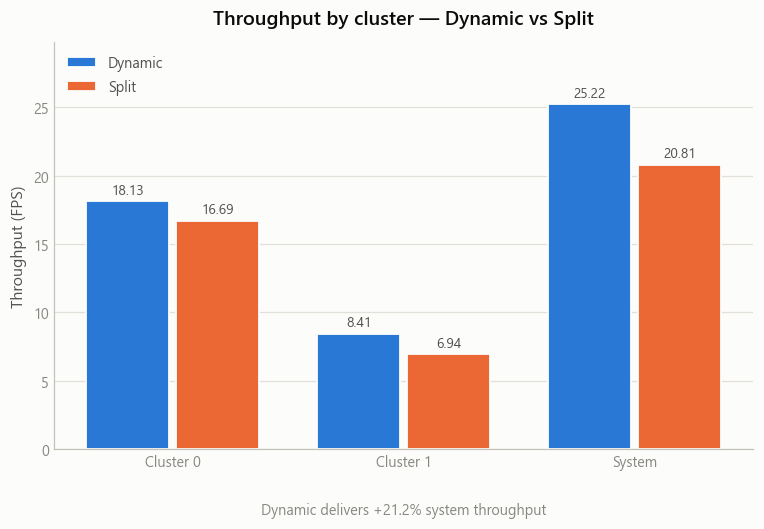

In [6]:
# ============================================================
# CHART 01 — FPS by cluster and system   [01_fps_by_cluster.png]
# ============================================================
order = ["Cluster 0", "Cluster 1", "System"]
piv = (df_fps.pivot(index="scope", columns="run", values="fps")
             .reindex(order)[RUN_ORDER])

x, width = np.arange(len(order)), 0.36
fig, ax = plt.subplots(figsize=(8.2, 4.8))

bars = {}
for i, run in enumerate(RUN_ORDER):
    off = (i - 0.5) * (width + 0.03)
    bars[run] = ax.bar(x + off, piv[run], width,
                       label=run, color=MODE_COLOR[run], **BAR_KW)
    label_bars(ax, bars[run], fmt="{:.2f}")

ax.set_xticks(x, order)
ax.set_ylabel("Throughput (FPS)")
ax.set_ylim(0, piv.to_numpy().max() * 1.18)
ax.set_title("Throughput by cluster — Dynamic vs Split")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")

gain = (piv.loc["System", "Dynamic"] / piv.loc["System", "Split"] - 1) * 100
ax.annotate(f"Dynamic delivers {gain:+.1f}% system throughput",
            xy=(0.5, -0.16), xycoords="axes fraction",
            ha="center", fontsize=9.5, color=MUTED)

finish(fig, "01_fps_by_cluster.png")

### 3.2 Rolling window FPS over the run — per cluster

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\02_window_fps_timeline_by_cluster.png


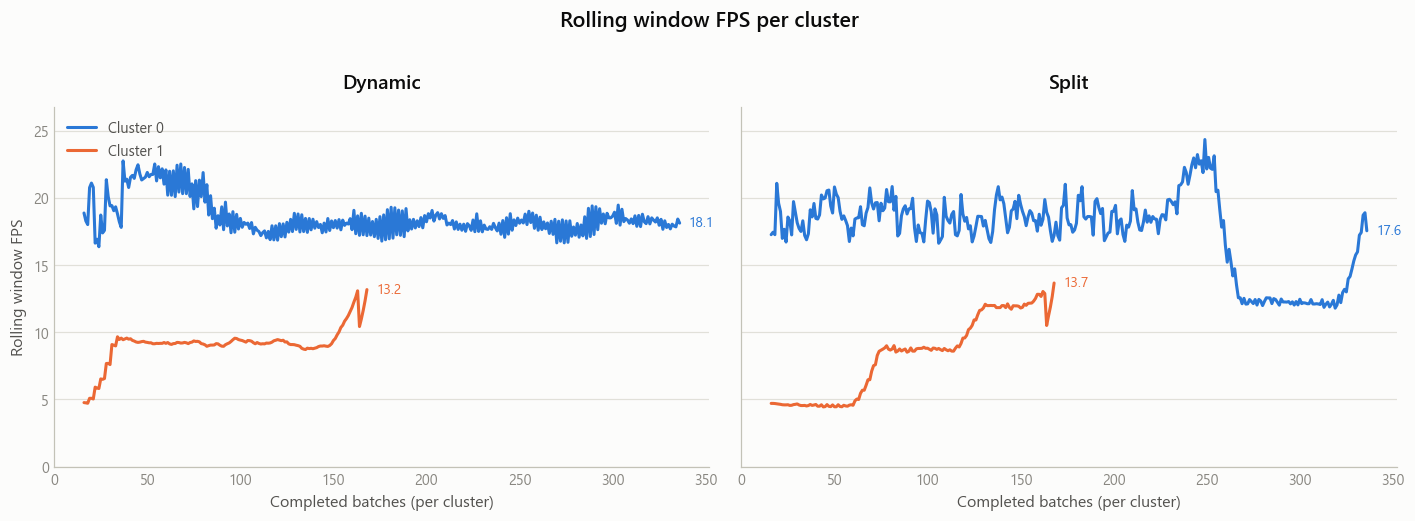

In [7]:
# ============================================================
# CHART 02 — window FPS timeline, small multiples per mode
#            [02_window_fps_timeline_by_cluster.png]
# Two modes x two clusters = 4 lines; faceting keeps each panel at 2 series
# rather than putting 4 hues on one axis.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
ymax = df_tl.window_fps.max() * 1.10

for ax, run in zip(axes, RUN_ORDER):
    sub_run = df_tl[df_tl.run == run]
    for cluster in ["Cluster 0", "Cluster 1"]:
        s = sub_run[sub_run.cluster == cluster].sort_values("done")
        ax.plot(s.done, s.window_fps, color=CLUSTER_COLOR[cluster],
                label=cluster, **LINE_KW)
        # selective direct label: the endpoint only
        if len(s):
            last = s.iloc[-1]
            ax.annotate(f"{last.window_fps:.1f}",
                        xy=(last.done, last.window_fps), xytext=(6, 0),
                        textcoords="offset points", va="center",
                        fontsize=9, color=CLUSTER_COLOR[cluster])
    ax.set_title(run)
    ax.set_xlabel("Completed batches (per cluster)")
    ax.set_ylim(0, ymax)
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("Rolling window FPS")
axes[0].legend(loc="upper left")
fig.suptitle("Rolling window FPS per cluster", fontsize=14,
             fontweight="semibold", color=INK, y=1.02)
fig.tight_layout()
finish(fig, "02_window_fps_timeline_by_cluster.png")

### 3.3 System-wide window FPS over the run

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\03_system_window_fps_timeline.png


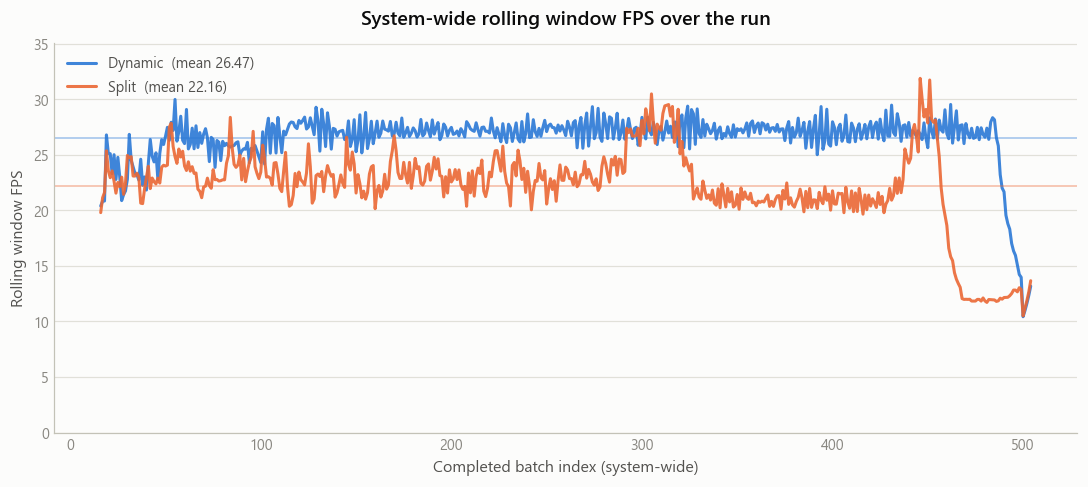

In [8]:
# ============================================================
# CHART 03 — system-wide window FPS  [03_system_window_fps_timeline.png]
# ============================================================
fig, ax = plt.subplots(figsize=(12, 4.6))

for run in RUN_ORDER:
    s = df_batch[df_batch.run == run].sort_values("batch")
    m = s.window_fps.mean()
    ax.plot(s.batch, s.window_fps, color=MODE_COLOR[run],
            label=f"{run}  (mean {m:.2f})", alpha=0.9, **LINE_KW)
    ax.axhline(m, color=MODE_COLOR[run], linewidth=1.0, alpha=0.45)

ax.set_xlabel("Completed batch index (system-wide)")
ax.set_ylabel("Rolling window FPS")
ax.set_title("System-wide rolling window FPS over the run")
ax.set_ylim(0, df_batch.window_fps.max() * 1.10)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")
finish(fig, "03_system_window_fps_timeline.png")

### 3.4 Distribution of window FPS

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\04_window_fps_distribution.png


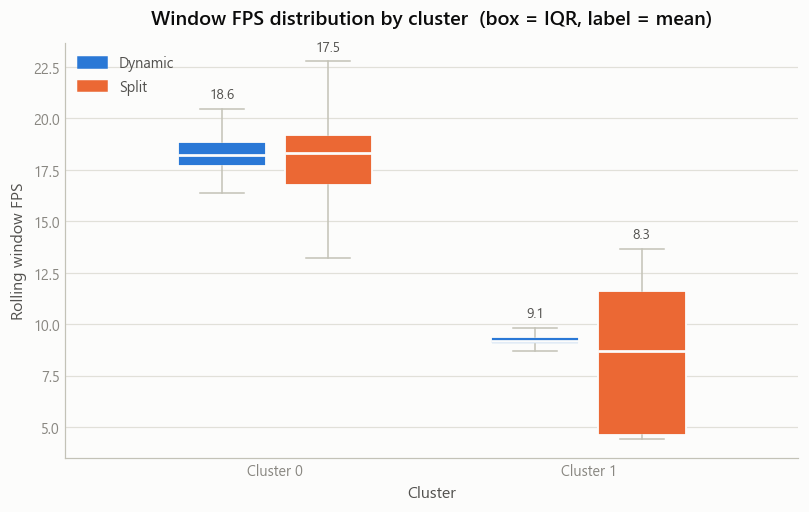

In [9]:
# ============================================================
# CHART 04 — window FPS distribution  [04_window_fps_distribution.png]
# ============================================================
clusters = ["Cluster 0", "Cluster 1"]
fig, ax = plt.subplots(figsize=(8.6, 4.9))

positions, data, colors = [], [], []
for ci, cluster in enumerate(clusters):
    for ri, run in enumerate(RUN_ORDER):
        vals = df_tl[(df_tl.cluster == cluster) & (df_tl.run == run)].window_fps.values
        positions.append(ci + (ri - 0.5) * 0.34)
        data.append(vals)
        colors.append(MODE_COLOR[run])

bp = ax.boxplot(data, positions=positions, widths=0.28, patch_artist=True,
                showfliers=False,
                medianprops=dict(color=SURFACE, linewidth=1.8),
                whiskerprops=dict(color=AXIS, linewidth=1.0),
                capprops=dict(color=AXIS, linewidth=1.0))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_edgecolor(SURFACE)
    patch.set_linewidth(1.2)

# selective direct labels — the mean of each box, placed clear of the whisker cap
for pos, vals, c in zip(positions, data, colors):
    if not len(vals):
        continue
    q1, q3 = np.percentile(vals, [25, 75])
    whisker_top = vals[vals <= q3 + 1.5 * (q3 - q1)].max()
    ax.annotate(f"{vals.mean():.1f}", xy=(pos, whisker_top),
                xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=9, color=INK_2)

handles = [plt.Rectangle((0, 0), 1, 1, color=MODE_COLOR[r]) for r in RUN_ORDER]
ax.legend(handles, RUN_ORDER, loc="upper left")
ax.set_xticks(range(len(clusters)), clusters)
ax.set_ylabel("Rolling window FPS")
ax.set_xlabel("Cluster")
ax.set_title("Window FPS distribution by cluster  (box = IQR, label = mean)")
ax.grid(axis="x", visible=False)
finish(fig, "04_window_fps_distribution.png")

## 4 · Latency

### 4.1 Mean service latency by device role

Cloud and edge service times differ by more than an order of magnitude, so they
get **one panel each on its own linear axis** — never two y-scales on one plot.

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\05_service_latency_by_role.png


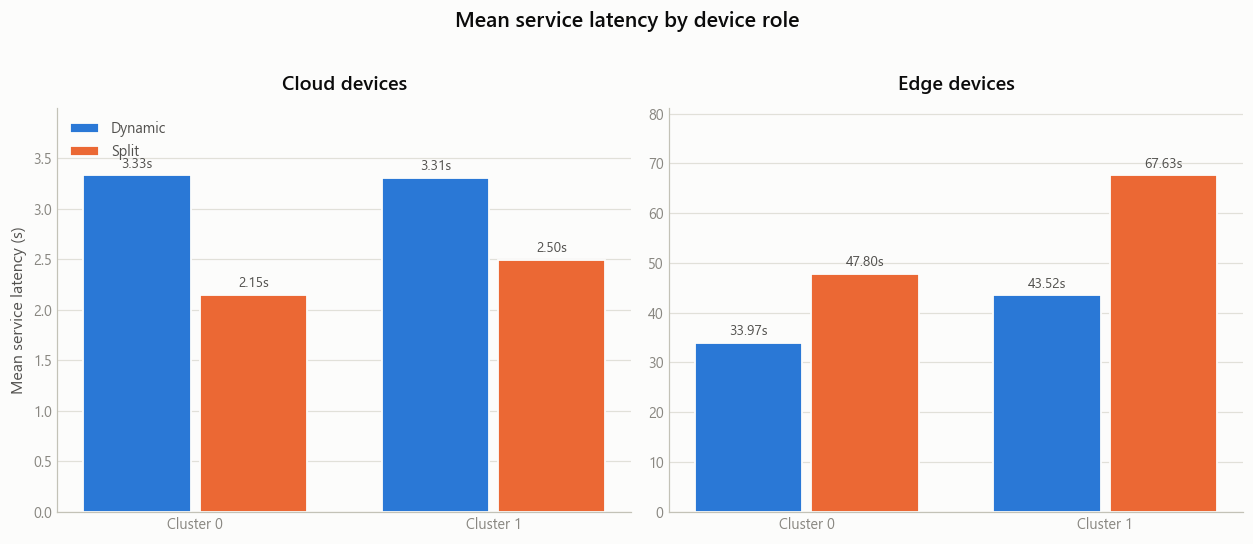

In [10]:
# ============================================================
# CHART 05 — mean service latency by role  [05_service_latency_by_role.png]
# ============================================================
svc = df_lat[df_lat.kind == "service"]
clusters = ["Cluster 0", "Cluster 1"]
roles = ["cloud", "edge"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
x, width = np.arange(len(clusters)), 0.36

for ax, role in zip(axes, roles):
    sub = svc[svc.role == role]
    piv = (sub.pivot(index="scope", columns="run", values="mean_ms")
              .reindex(clusters)[RUN_ORDER] / 1000.0)     # ms -> s
    for i, run in enumerate(RUN_ORDER):
        off = (i - 0.5) * (width + 0.03)
        b = ax.bar(x + off, piv[run], width, label=run,
                   color=MODE_COLOR[run], **BAR_KW)
        label_bars(ax, b, fmt="{:.2f}s")
    ax.set_xticks(x, clusters)
    ax.set_title(f"{role.capitalize()} devices")
    ax.set_ylim(0, piv.to_numpy().max() * 1.20)
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("Mean service latency (s)")
axes[0].legend(loc="upper left")
fig.suptitle("Mean service latency by device role", fontsize=14,
             fontweight="semibold", color=INK, y=1.02)
fig.tight_layout()
finish(fig, "05_service_latency_by_role.png")

### 4.2 End-to-end latency profile

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\06_e2e_latency_profile.png


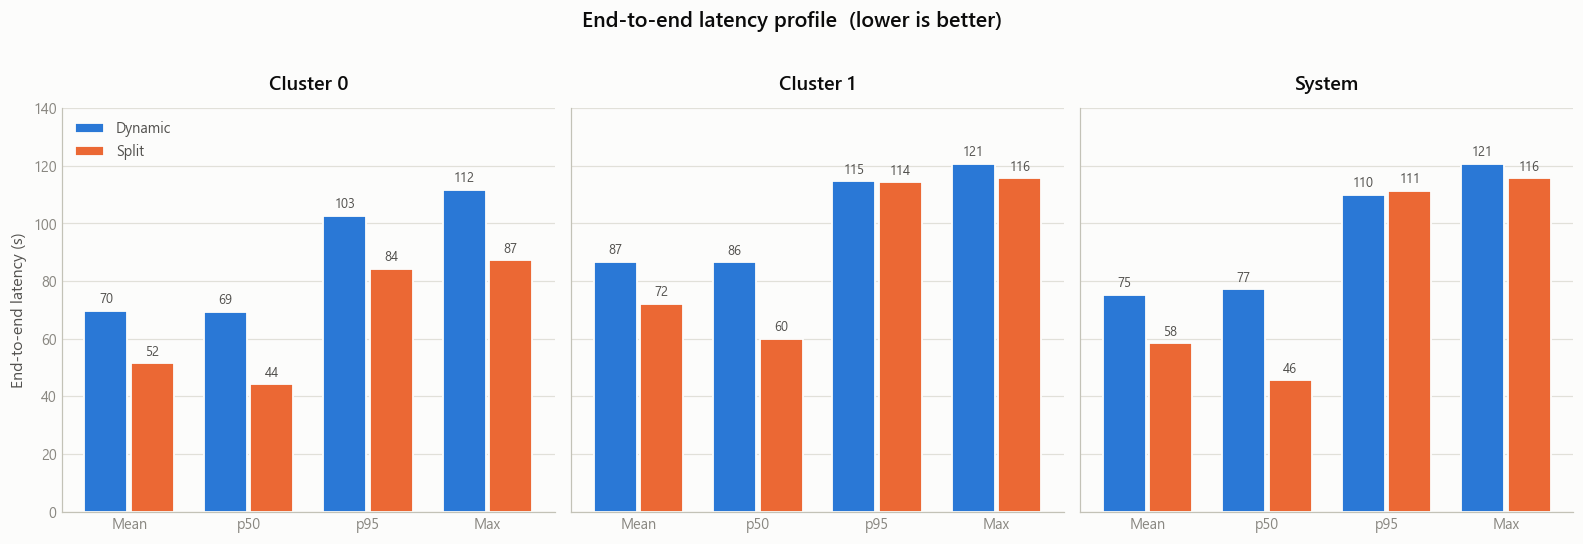

In [11]:
# ============================================================
# CHART 06 — e2e latency profile  [06_e2e_latency_profile.png]
# ============================================================
e2e = df_lat[df_lat.kind == "e2e"]
stats = [("mean_ms", "Mean"), ("p50_ms", "p50"), ("p95_ms", "p95"), ("max_ms", "Max")]
scopes = ["Cluster 0", "Cluster 1", "System"]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), sharey=True)
x, width = np.arange(len(stats)), 0.36
ymax = e2e[[c for c, _ in stats]].to_numpy().max() / 1000.0

for ax, scope in zip(axes, scopes):
    sub = e2e[e2e.scope == scope].set_index("run")
    for i, run in enumerate(RUN_ORDER):
        vals = [sub.loc[run, col] / 1000.0 for col, _ in stats]
        off = (i - 0.5) * (width + 0.03)
        b = ax.bar(x + off, vals, width, label=run,
                   color=MODE_COLOR[run], **BAR_KW)
        label_bars(ax, b, fmt="{:.0f}", fontsize=8.5)
    ax.set_xticks(x, [lbl for _, lbl in stats])
    ax.set_title(scope)
    ax.set_ylim(0, ymax * 1.16)
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("End-to-end latency (s)")
axes[0].legend(loc="upper left")
fig.suptitle("End-to-end latency profile  (lower is better)", fontsize=14,
             fontweight="semibold", color=INK, y=1.02)
fig.tight_layout()
finish(fig, "06_e2e_latency_profile.png")

## 5 · Device utilization

### 5.1 Utilization by cluster and role

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\07_utilization_by_role.png


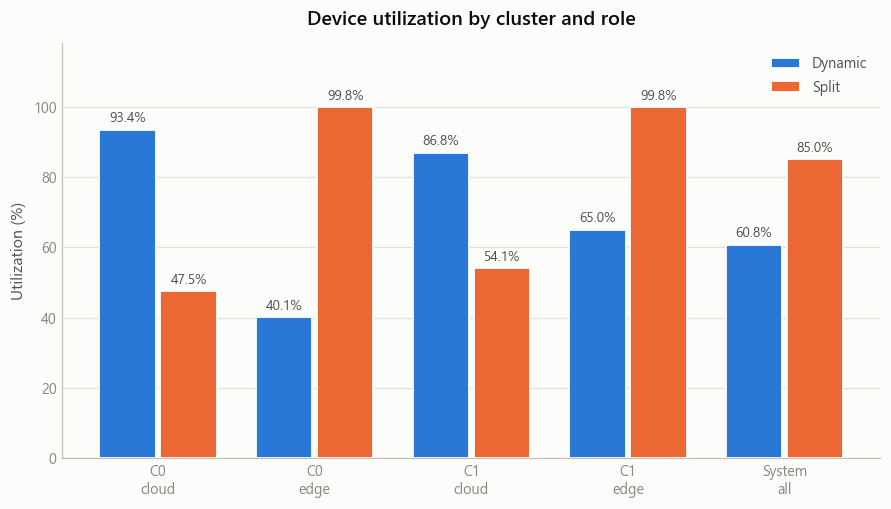

In [12]:
# ============================================================
# CHART 07 — utilization by cluster & role  [07_utilization_by_role.png]
# ============================================================
rows = [("Cluster 0", "cloud"), ("Cluster 0", "edge"),
        ("Cluster 1", "cloud"), ("Cluster 1", "edge"),
        ("System",    "all")]
labels = ["C0\ncloud", "C0\nedge", "C1\ncloud", "C1\nedge", "System\nall"]

idx = df_utc.set_index(["run", "scope", "role"])
x, width = np.arange(len(rows)), 0.36
fig, ax = plt.subplots(figsize=(9.6, 4.9))

for i, run in enumerate(RUN_ORDER):
    vals = [idx.loc[(run, s, r), "utilization"] for s, r in rows]
    vals = [float(np.ravel(v)[0]) for v in vals]
    off = (i - 0.5) * (width + 0.03)
    b = ax.bar(x + off, vals, width, label=run, color=MODE_COLOR[run], **BAR_KW)
    label_bars(ax, b, fmt="{:.1f}%", fontsize=9)

ax.set_xticks(x, labels)
ax.set_ylabel("Utilization (%)")
ax.set_ylim(0, 118)
ax.set_title("Device utilization by cluster and role")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")          # upper-left is occupied by the 93.4% bar
finish(fig, "07_utilization_by_role.png")

### 5.2 Per-device utilization

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\08_device_utilization.png


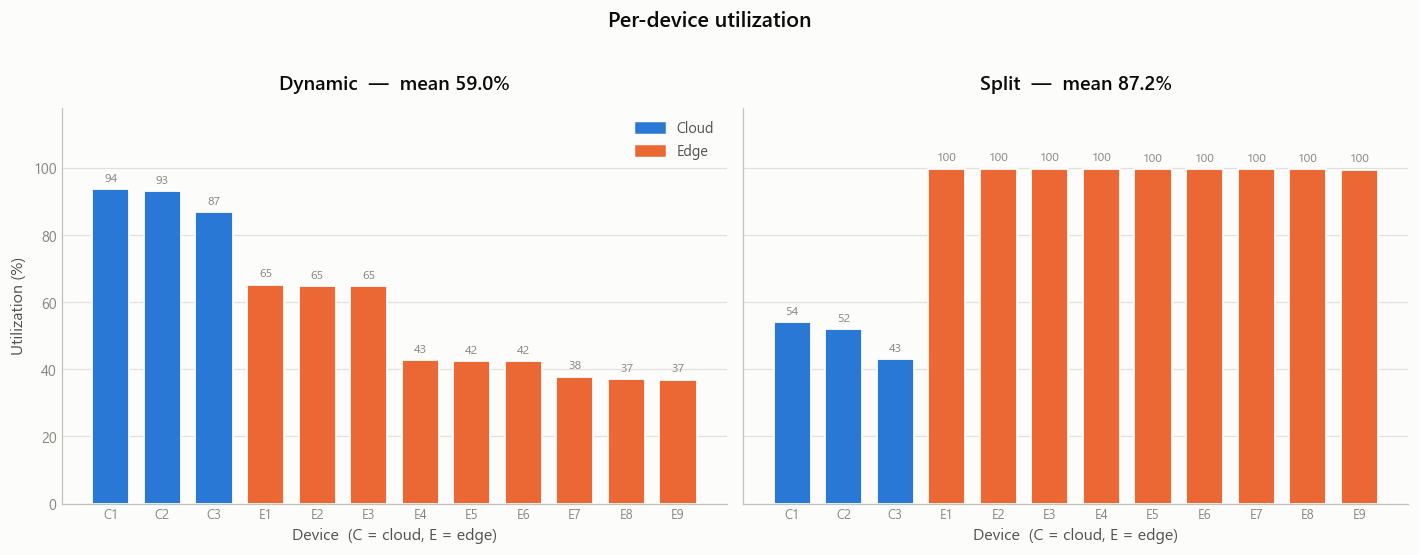

In [13]:
# ============================================================
# CHART 08 — per-device utilization  [08_device_utilization.png]
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.9), sharey=True)

for ax, run in zip(axes, RUN_ORDER):
    sub = (df_utd[df_utd.run == run]
           .sort_values(["role", "utilization"], ascending=[True, False])
           .reset_index(drop=True))
    pos = np.arange(len(sub))
    b = ax.bar(pos, sub.utilization,
               color=[ROLE_COLOR[r] for r in sub.role], width=0.72, **BAR_KW)
    label_bars(ax, b, fmt="{:.0f}", fontsize=8, color=MUTED)
    ticks = sub.groupby("role").cumcount() + 1          # number within each role
    ax.set_xticks(pos, [f"{r[0].upper()}{n}" for r, n in zip(sub.role, ticks)],
                  fontsize=8.5)
    ax.set_title(f"{run}  —  mean {sub.utilization.mean():.1f}%")
    ax.set_xlabel("Device  (C = cloud, E = edge)")
    ax.set_ylim(0, 118)
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=ROLE_COLOR[r]) for r in ["cloud", "edge"]]
axes[0].set_ylabel("Utilization (%)")
axes[0].legend(handles, ["Cloud", "Edge"], loc="upper right")
fig.suptitle("Per-device utilization", fontsize=14,
             fontweight="semibold", color=INK, y=1.02)
fig.tight_layout()
finish(fig, "08_device_utilization.png")

## 6 · Accuracy (mAP)

The check in §2 shows the two modes produce **bit-identical** mAP — scheduling
changes throughput and latency, not detection quality. So the mAP charts are
drawn per cluster from the shared values rather than as two overlapping series.

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\09_map_by_window.png


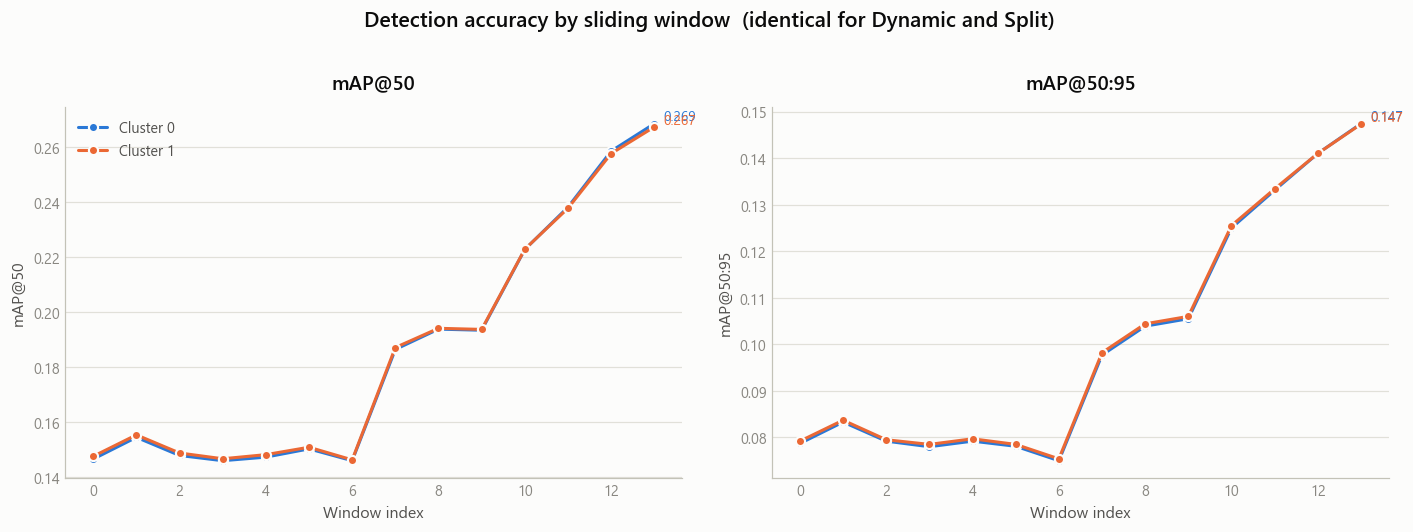

In [14]:
# ============================================================
# CHART 09 — mAP by window  [09_map_by_window.png]
# ============================================================
src = df_mw[df_mw.run == "Dynamic"] if MAP_IDENTICAL else df_mw
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))

for ax, (col, title) in zip(axes, [("mAP50", "mAP@50"), ("mAP50_95", "mAP@50:95")]):
    for cluster in ["Cluster 0", "Cluster 1"]:
        s = src[src.cluster == cluster].sort_values("window")
        ax.plot(s.window, s[col], color=CLUSTER_COLOR[cluster], label=cluster,
                marker="o", **LINE_KW, **MARK_KW)
        last = s.iloc[-1]
        ax.annotate(f"{last[col]:.3f}", xy=(last.window, last[col]),
                    xytext=(6, 2), textcoords="offset points",
                    fontsize=9, color=CLUSTER_COLOR[cluster])
    ax.set_title(title)
    ax.set_xlabel("Window index")
    ax.set_ylabel(title)
    ax.grid(axis="x", visible=False)

axes[0].legend(loc="upper left")
note = "identical for Dynamic and Split" if MAP_IDENTICAL else "per run"
fig.suptitle(f"Detection accuracy by sliding window  ({note})", fontsize=14,
             fontweight="semibold", color=INK, y=1.02)
fig.tight_layout()
finish(fig, "09_map_by_window.png")

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\10_map_summary.png


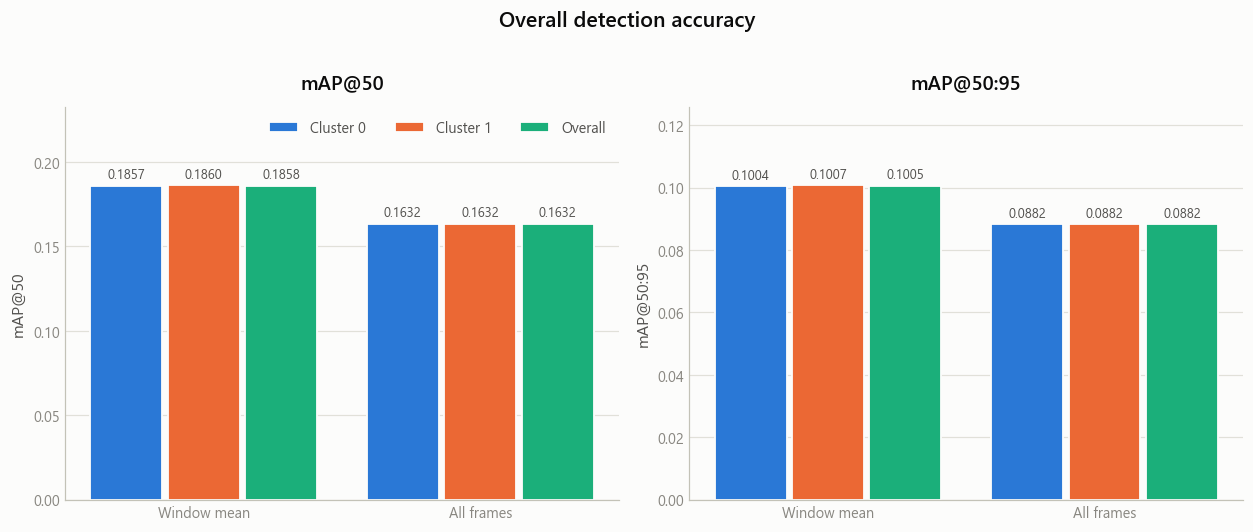

In [15]:
# ============================================================
# CHART 10 — overall mAP summary  [10_map_summary.png]
# Three scopes x two aggregations; slot 3 (aqua) is in play, so every bar
# carries a visible direct label (the sub-3:1 relief rule).
# ============================================================
src = df_ms[df_ms.run == "Dynamic"] if MAP_IDENTICAL else df_ms
scopes = ["Cluster 0", "Cluster 1", "Overall"]
scope_color = {"Cluster 0": S1, "Cluster 1": S2, "Overall": S3}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7))
aggs = ["WINDOW", "ALL"]
x, width = np.arange(len(aggs)), 0.26

for ax, (col, title) in zip(axes, [("mAP50", "mAP@50"), ("mAP50_95", "mAP@50:95")]):
    piv = src.pivot_table(index="agg_kind", columns="scope", values=col).reindex(aggs)
    for i, scope in enumerate(scopes):
        off = (i - 1) * (width + 0.02)
        b = ax.bar(x + off, piv[scope], width, label=scope,
                   color=scope_color[scope], **BAR_KW)
        label_bars(ax, b, fmt="{:.4f}", fontsize=8.5)
    ax.set_xticks(x, ["Window mean", "All frames"])
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.set_ylim(0, piv.to_numpy().max() * 1.25)
    ax.grid(axis="x", visible=False)

axes[0].legend(loc="upper right", ncol=3)
fig.suptitle("Overall detection accuracy", fontsize=14,
             fontweight="semibold", color=INK, y=1.02)
fig.tight_layout()
finish(fig, "10_map_summary.png")

## 7 · Headline comparison

All four metrics indexed against **Split = baseline**, on one axis. Each row is
labelled with the direction that counts as an improvement, so the sign of the
bar is never read as "good" on its own.

saved -> D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs\11_dynamic_vs_split_summary.png


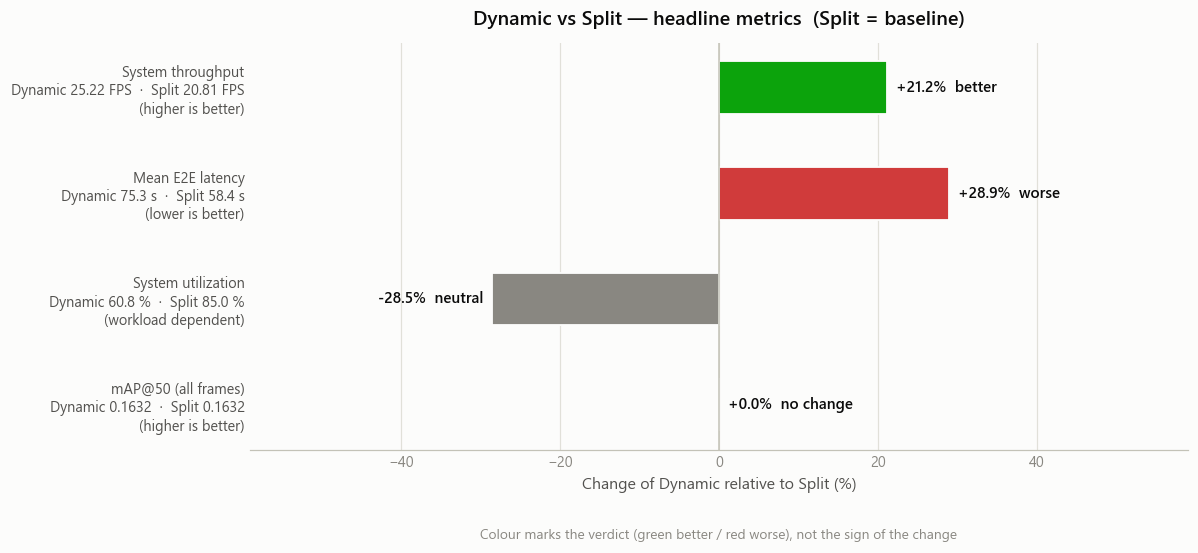

In [16]:
# ============================================================
# CHART 11 — Dynamic vs Split summary  [11_dynamic_vs_split_summary.png]
# ============================================================
fps_sys  = df_fps.set_index(["run", "scope"]).loc[:, "fps"]
e2e_sys  = df_lat[(df_lat.kind == "e2e") & (df_lat.scope == "System")].set_index("run")
util_sys = df_utc[(df_utc.scope == "System")].set_index("run")
map_all  = df_ms[(df_ms.scope == "Overall") & (df_ms["agg_kind"] == "ALL")].set_index("run")

# `goal`: +1 = higher is better, -1 = lower is better, 0 = no better/worse.
# Colour is keyed to the VERDICT, never to the sign of the change — a +28.9%
# latency move is a regression and must not be painted like a +21.2% FPS gain.
metrics = [
    ("System throughput",  fps_sys[("Dynamic", "System")], fps_sys[("Split", "System")],
     "{:.2f} FPS", "higher is better", +1),
    ("Mean E2E latency",   e2e_sys.loc["Dynamic", "mean_ms"] / 1000,
                           e2e_sys.loc["Split", "mean_ms"] / 1000,
     "{:.1f} s", "lower is better", -1),
    ("System utilization", util_sys.loc["Dynamic", "utilization"],
                           util_sys.loc["Split", "utilization"],
     "{:.1f} %", "workload dependent", 0),
    ("mAP@50 (all frames)", map_all.loc["Dynamic", "mAP50"],
                            map_all.loc["Split", "mAP50"],
     "{:.4f}", "higher is better", +1),
]

GOOD, BAD, NEUTRAL = "#0ca30c", "#d03b3b", MUTED   # status tokens + neutral

pct, colors, verdicts = [], [], []
for _, dyn, spl, _, _, goal in metrics:
    p = (dyn / spl - 1) * 100
    score = goal * np.sign(p)
    pct.append(p)
    colors.append(GOOD if score > 0 else BAD if score < 0 else NEUTRAL)
    verdicts.append("better" if score > 0 else "worse" if score < 0 else "no change"
                    if p == 0 else "neutral")

y = np.arange(len(metrics))[::-1]
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.barh(y, pct, height=0.5, color=colors, **BAR_KW)
ax.axvline(0, color=AXIS, linewidth=1.0)

# The verdict is spelled out beside every bar, so the good/bad reading never
# rests on colour alone.
for yi, p, v in zip(y, pct, verdicts):
    ax.annotate(f"{p:+.1f}%  {v}", xy=(p, yi), xytext=(6 if p >= 0 else -6, 0),
                textcoords="offset points", va="center",
                ha="left" if p >= 0 else "right",
                fontsize=10, fontweight="semibold", color=INK)

tick_labels = [f"{name}\nDynamic {fmt.format(dyn)}  ·  Split {fmt.format(spl)}\n({hint})"
               for name, dyn, spl, fmt, hint, _ in metrics]
ax.set_yticks(y, tick_labels, fontsize=9.5)
ax.tick_params(axis="y", colors=INK_2)
lim = max(abs(p) for p in pct) * 1.9 + 4
ax.set_xlim(-lim, lim)
ax.set_xlabel("Change of Dynamic relative to Split (%)")
ax.set_title("Dynamic vs Split — headline metrics  (Split = baseline)")
ax.annotate("Colour marks the verdict (green better / red worse), not the sign of the change",
            xy=(0.5, -0.22), xycoords="axes fraction", ha="center",
            fontsize=9, color=MUTED)
ax.grid(axis="y", visible=False)
finish(fig, "11_dynamic_vs_split_summary.png", hide_spines=("top", "right", "left"))

## 8 · Saved images

In [17]:
print(f"{len(SAVED)} charts written to {IMG_DIR}\n")
for name in SAVED:
    p = IMG_DIR / name
    print(f"  {name:<42} {p.stat().st_size/1024:8.1f} KB")

pd.DataFrame({"chart": SAVED,
              "path": [str(IMG_DIR / n) for n in SAVED]})

11 charts written to D:\SplitInference\Optimizer\split_inference_test\results\July27th\imgs

  01_fps_by_cluster.png                          88.5 KB
  02_window_fps_timeline_by_cluster.png         242.1 KB
  03_system_window_fps_timeline.png             284.1 KB
  04_window_fps_distribution.png                 83.0 KB
  05_service_latency_by_role.png                127.6 KB
  06_e2e_latency_profile.png                    125.3 KB
  07_utilization_by_role.png                     98.4 KB
  08_device_utilization.png                     113.1 KB
  09_map_by_window.png                          223.0 KB
  10_map_summary.png                            113.5 KB
  11_dynamic_vs_split_summary.png               215.6 KB


,chart,path
0,01_fps_by_cluster.png,D:\SplitInference\Optimizer\split_inference_te...
1,02_window_fps_timeline_by_cluster.png,D:\SplitInference\Optimizer\split_inference_te...
2,03_system_window_fps_timeline.png,D:\SplitInference\Optimizer\split_inference_te...
3,04_window_fps_distribution.png,D:\SplitInference\Optimizer\split_inference_te...
4,05_service_latency_by_role.png,D:\SplitInference\Optimizer\split_inference_te...
5,06_e2e_latency_profile.png,D:\SplitInference\Optimizer\split_inference_te...
6,07_utilization_by_role.png,D:\SplitInference\Optimizer\split_inference_te...
7,08_device_utilization.png,D:\SplitInference\Optimizer\split_inference_te...
8,09_map_by_window.png,D:\SplitInference\Optimizer\split_inference_te...
9,10_map_summary.png,D:\SplitInference\Optimizer\split_inference_te...
